In [12]:
import sys
sys.path.insert(0, '..')

In [13]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
import chainconsumer as cc


%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import interpax as ipx


In [14]:
wid = 80
oversample = 4

nwavels = 20
npoly=4

n_modes = 20
n_zernikes = 50

resolved_wid = 1

optics = NICMOSCoronagraph(512, wid, oversample, n_modes=n_modes, n_zernikes=n_zernikes, turboklip="../data/turboklip.npz")

detector = NICMOSDetector(oversample, wid)

spectrum_basis = np.ones((nwavels, npoly))


ddir = '../data/NICMOS-LAPL-DD2/LAPL_DATA_DD2/comtemp_flats-DD2/'
# ddir = '../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/repaired/'

flatdir = '../data/NICMOS-LAPL-DD2/LAPL_HOLEFLATS_DD2/'

vects = np.load("../data/iterative_spectrum_basis_F110W.npy")[:,:npoly]
assert vects.shape == (nwavels, npoly)
spectrum_basis = vects/np.sqrt(np.mean(vects**2, axis=0))

extra_bad = np.full((wid,wid), False).at[30:50, 30:50].set(True)#.at[:, 35:45].set(True)


exposures_single = [
    # exposure_from_file(ddir + 'n8zu81fbq_o_clc_calf.fits', SinglePointFit(spectrum_basis, "F110W"), crop=wid, extra_bad=None, flatcorr=flatdir),

    exposure_from_file(ddir + 'n8zu67d0q_o_clc_calf.fits', SinglePointFit(spectrum_basis, "F110W"), crop=wid, extra_bad=None, flatcorr=flatdir),

    # exposure_from_file(ddir + 'n8zu85ndq_m_clc_calf.fits', SinglePointFit(spectrum_basis, "F160W"), crop=wid),
]


223.9605 5.4
Version 4.1.1
37.5699


ADCZERO                    0.0 / analog-digital conversion zero level (DN)       [astropy.io.fits.card]


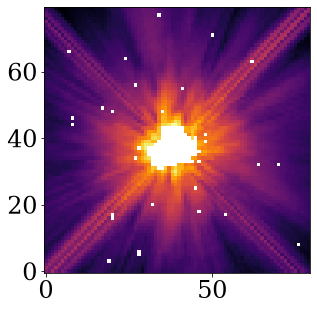

In [15]:
plt.imshow(exposures_single[0].data**0.125)

In [16]:
256-181,256-44

(75, 212)

In [17]:
exposures_single[0].hdr["TARSIAFY"]

210.327

In [18]:
# np.array([
#         256-181 - np.array(exp.hdr["TARSIAFX"],dtype=float), 
#         256-44 - np.array(exp.hdr["TARSIAFY"],dtype=float)
#     ])*0.075

In [19]:
exposures_single[0].target

'HD181327'

In [20]:
(np.nansum(exposures_single[0].data)/nwavels)*4

Array(42657.99409885, dtype=float64)

In [ ]:
params = {
    "spectrum": {},
    # "primary_opd": {},
    "primary_klip": {},
    "primary_low": {},
    "primary_tilt": {},
    "cold_mask_opd": {},
    "cold_mask_tilt": {},
    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_shear": {},
    "primary_shear": {},
    "cold_mask_scale": {},
    "primary_rot": {},

    "bias": {},
    "occulter_radius": 0.7,
    "occulter_coeffs": np.zeros(2)+1,
    "fnumber": 45.7,
}


for idx, exp in enumerate(exposures_single):
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set((np.nansum(exp.data)/nwavels)*5)

    params["primary_tilt"][exp.fit.get_key(exp, "primary_tilt")] = np.array([-0.75, -0.05])*0.075
    # params["cold_mask_tilt"][exp.fit.get_key(exp, "cold_mask_tilt")] = np.array([-0.2167105 , -0.17420508])#*0.
    params["cold_mask_tilt"][exp.fit.get_key(exp, "cold_mask_tilt")] = np.array([
        np.array(exp.hdr["TARSIAFX"],dtype=float) - (256-181), 
        np.array(exp.hdr["TARSIAFY"],dtype=float) - (256-44)
    ])*0.075

    params["primary_klip"][exp.fit.get_key(exp, "primary_klip")] = np.zeros(())

    # params["primary_opd"][exp.fit.get_key(exp, "primary_opd")] = np.zeros((n_modes, n_modes))
    params["primary_low"][exp.fit.get_key(exp, "primary_low")] = np.zeros((n_zernikes))
    params["cold_mask_opd"][exp.fit.get_key(exp, "cold_mask_opd")] = np.array([120.])

    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.array([13.,10.]) #np.asarray([-13.,-7.])#
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = 0.1#-90.
    params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -0.6##-90.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])
    params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    

model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))

params = set_array(ModelParams(params))

TypeError: cannot reshape array of shape (2025,) (size 2025) into shape (20, 20) (size 400)

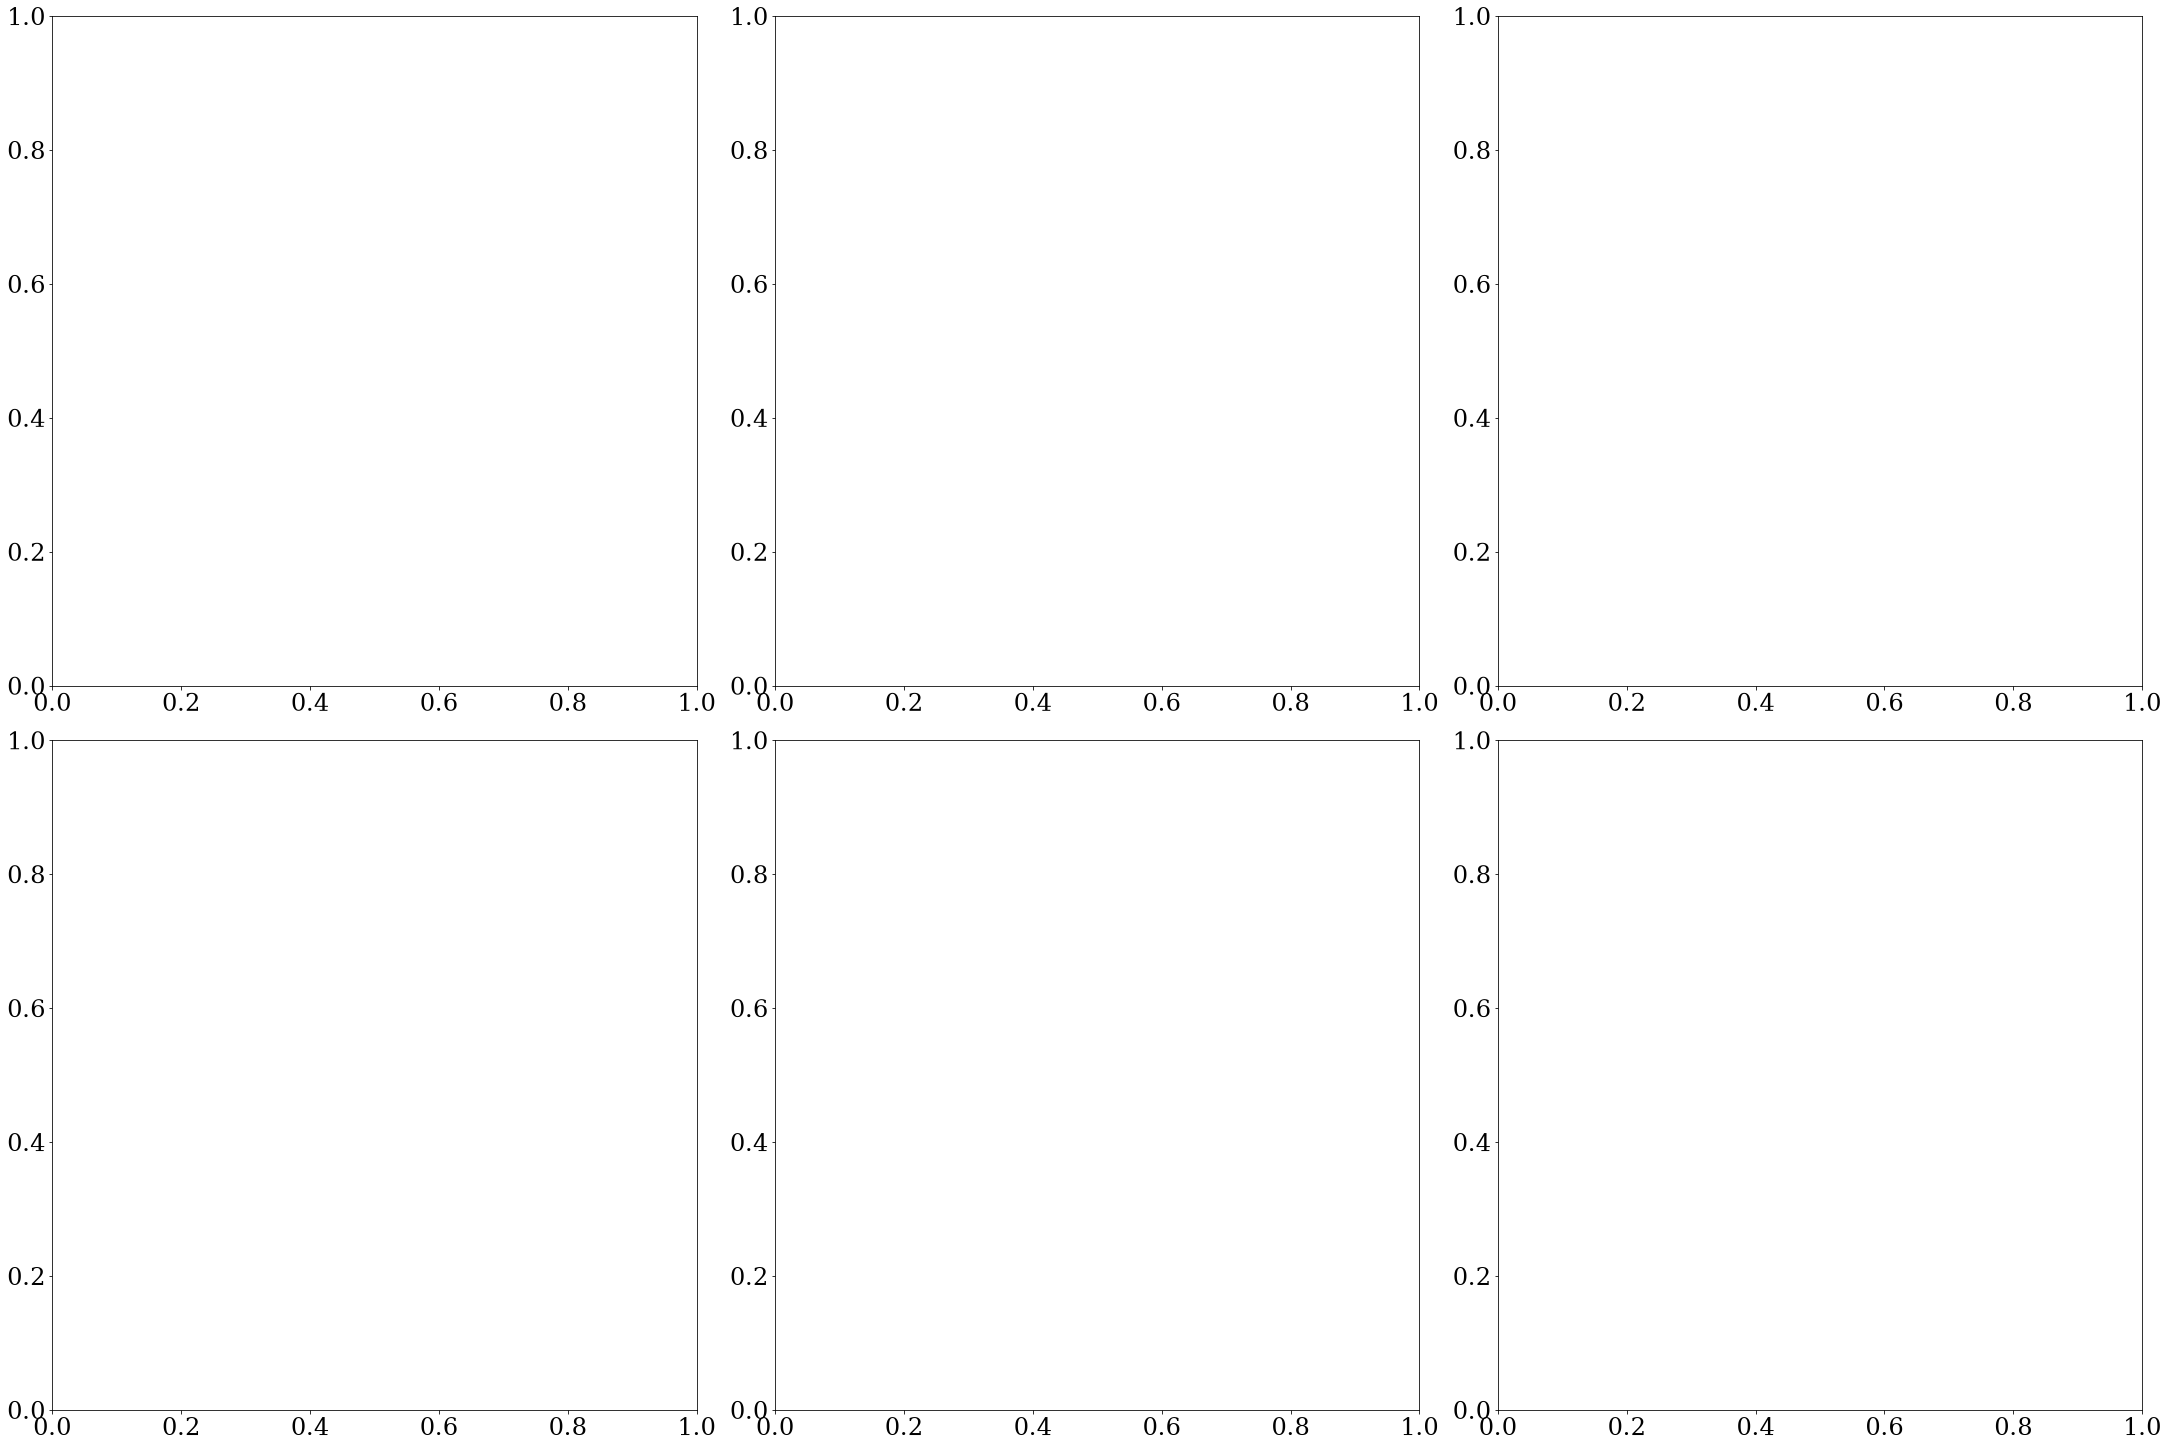

In [22]:
plot_comparison(model_single, params, exposures_single, percentile=99, wf_size=512)

In [ ]:
# stop

In [ ]:
g = 5e-2


things_start = {
    "spectrum": sgd(g*3, 30.),
    "primary_tilt": sgd(g*10, 15.),
    "cold_mask_tilt": sgd(g*5, 0),
    "cold_mask_opd": sgd(g*3, 40),

    # "bias": sgd(g*3, 50),
    # "cold_mask_shift": sgd(g*3, 70),
    # "cold_mask_rot": sgd(g*0.2, 85),
    # "primary_rot": sgd(g*1, 85),

    # "primary_low": sgd(g*2, 150),
    # "primary_klip": sgd(g*0.2, 200),

    # "cold_mask_scale": sgd(g*5, 100),
    # "cold_mask_shear": sgd(g*10, 100),

    # # "primary_scale": sgd(g*5, 100),
    # "primary_shear": sgd(g*10, 100),

    # "occulter_radius": sgd(g*1., 120),
    # # # "occulter_coeffs": sgd(g*1, 120),
    # # # # "fnumber": sgd(g*2., 150),
}

groups = list(things.keys())

In [ ]:
orig_params = params.params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [ ]:
losses, params_history = optimise_new(
    opt_params, model_single, exposures_single, things_start, 50,
    precond_method="gn_exact", precond_kwargs=dict(chunk=16))

(20, 20) 20


  0%|          | 0/400 [00:00<?, ?it/s]

(20, 20) 20


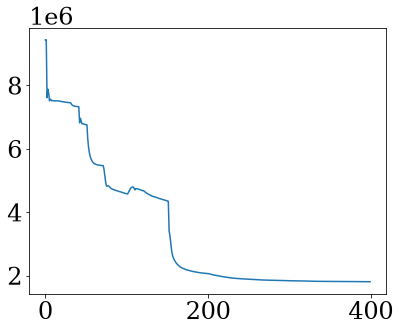

In [ ]:
plt.plot(losses[:])

14
(20, 20) 20
(20, 20) 20
23.969002001724892


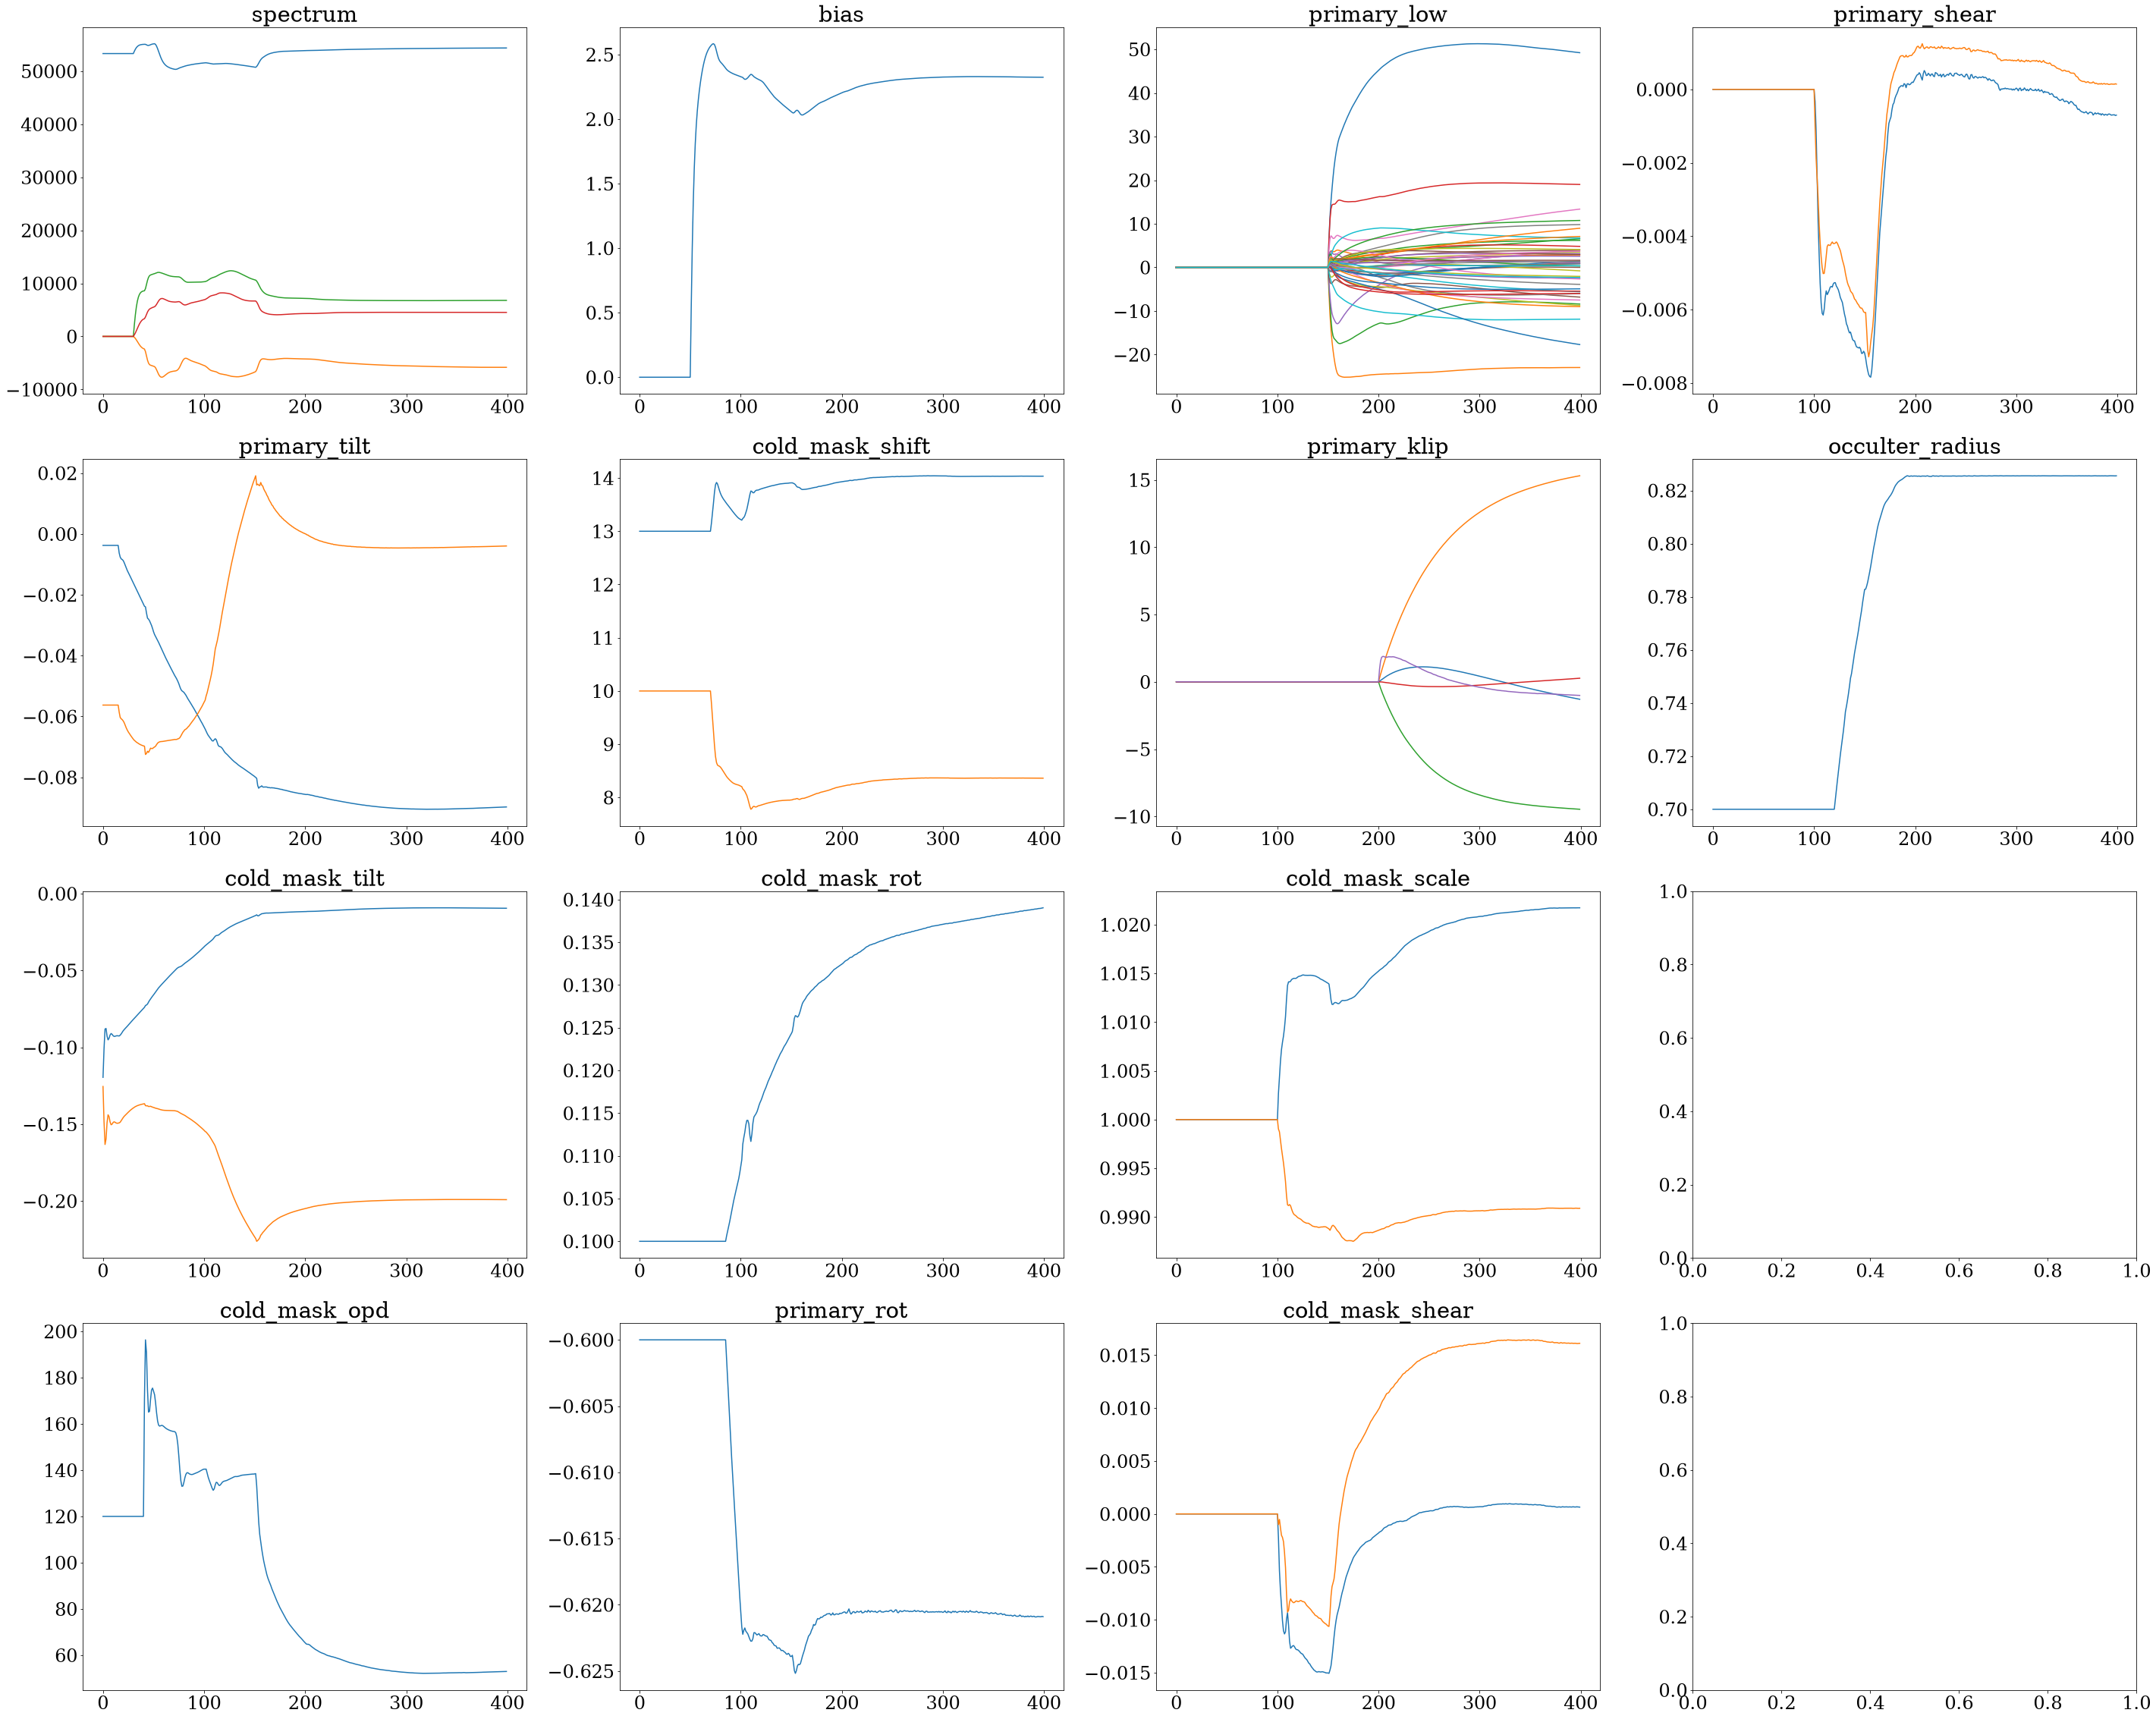

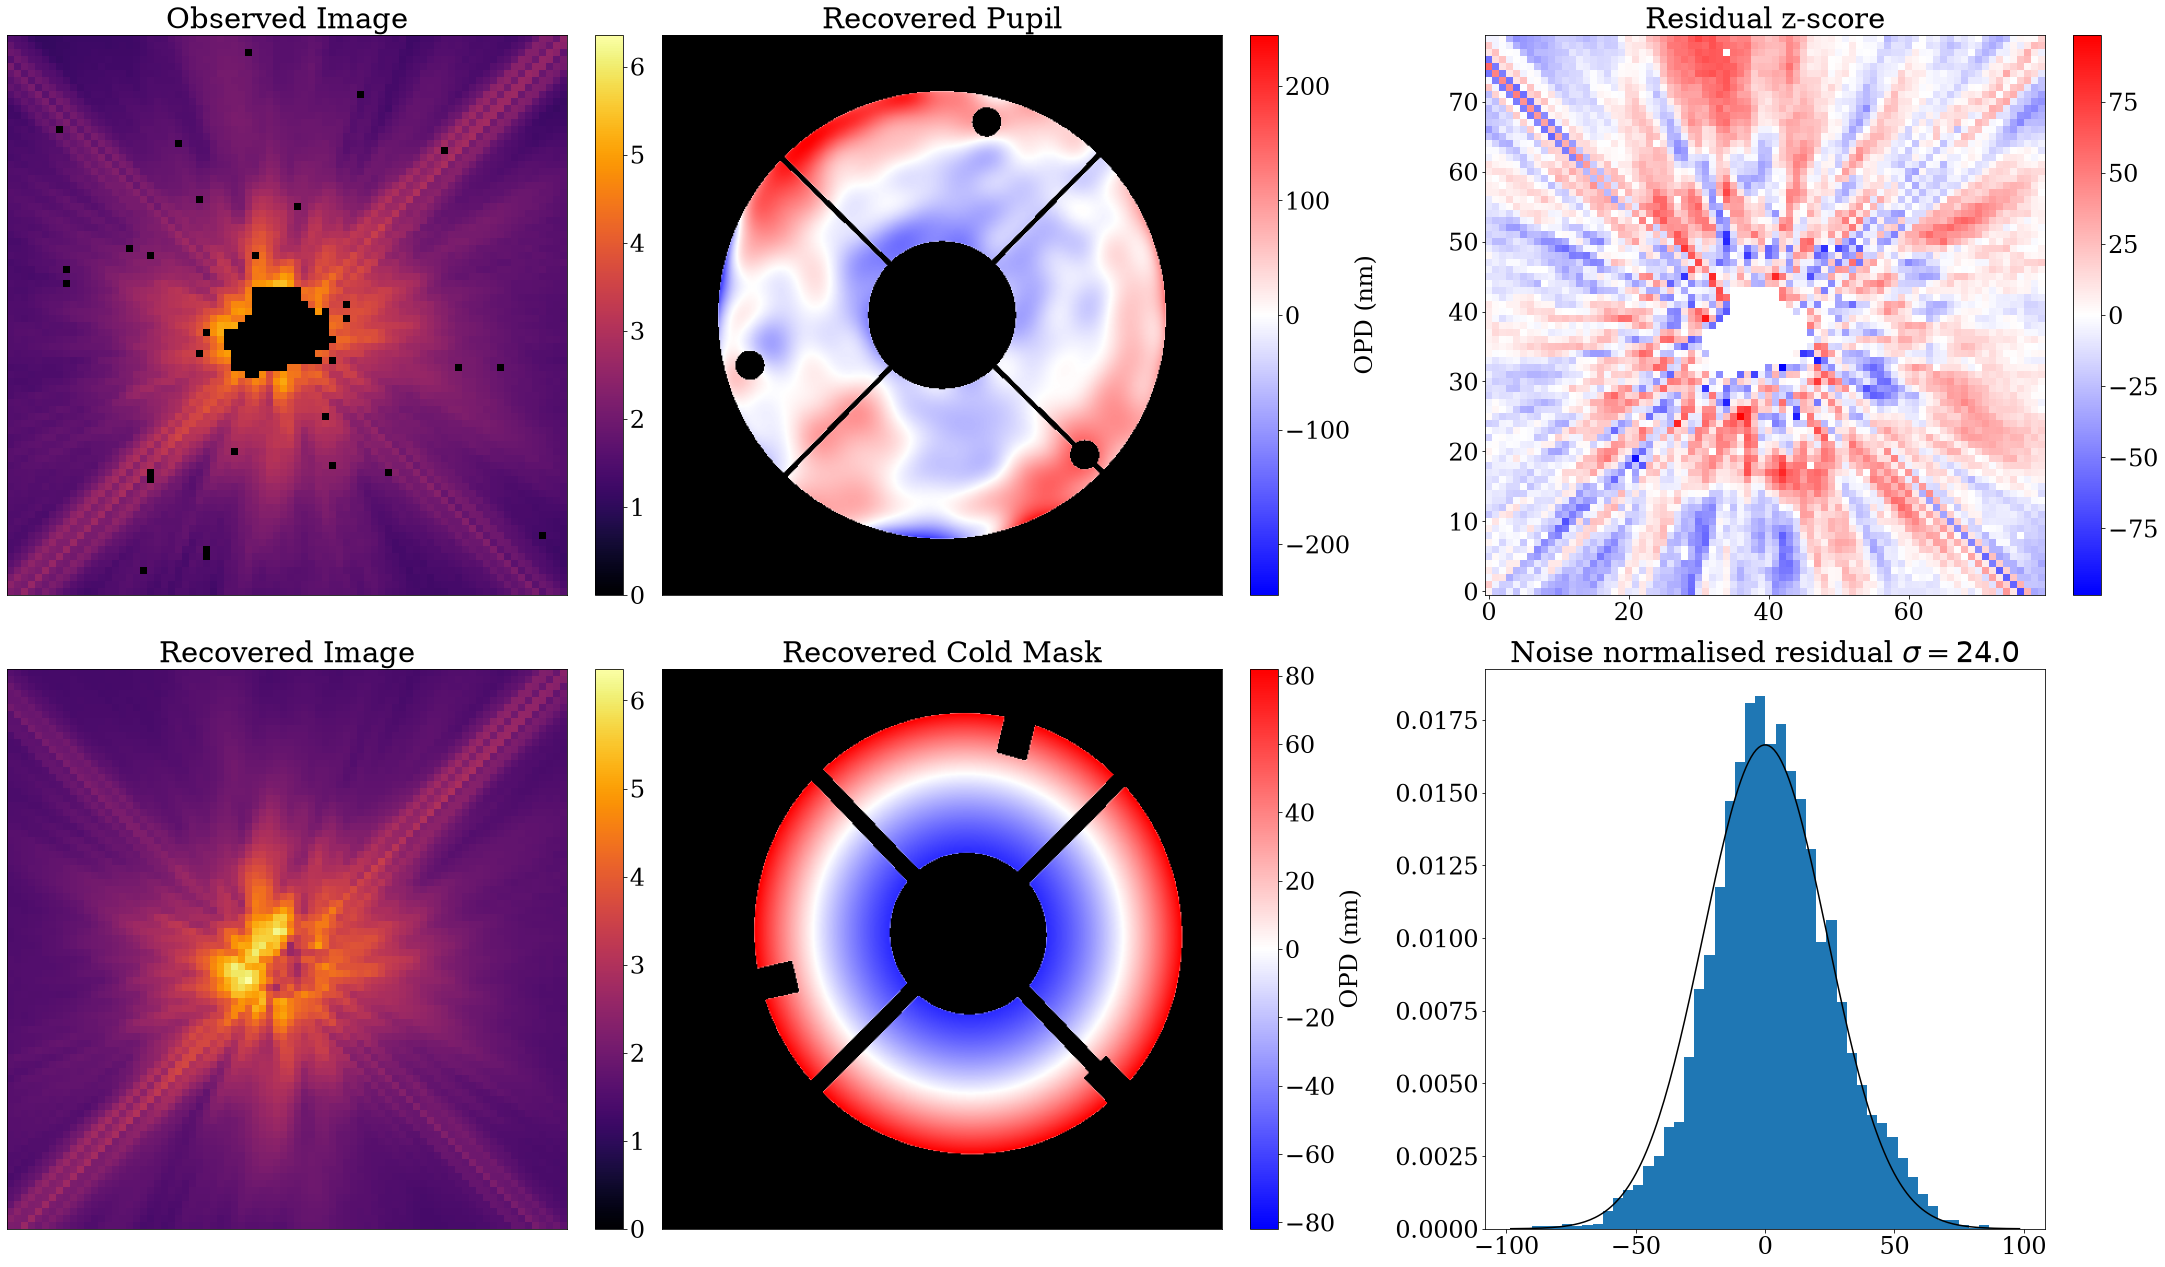

In [ ]:
plot_params(params_history, list(things_start.keys()), xw = 4)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, percentile=100, quadrature=False, wf_size=512, klip=True)